# Random Field Relaxation Test for `sim_pfc_std`

This notebook initializes a random field around `psi0 = -0.4` with standard deviation `sigma = 0.5`, runs the standard PFC simulation for 1000 steps, and plots the field before and after relaxation.

The standard model requires `rho0` and `Gamma_s` as well, so this notebook uses the repository baseline values `rho0 = 1.0` and `Gamma_s = 0.75`.

In [17]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "PFC").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root containing the PFC package.")

ROOT = find_repo_root(Path.cwd().resolve())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from PFC.stdPFC import sim_pfc_std

plt.rcParams.update({
    "figure.figsize": (6.5, 5.5),
    "image.cmap": "gray",
})
psi0 = -0.4
sigma = 0.5

dx = 0.5
dy = 0.5

Nx = 2 ** 8
Ny = 2 ** 8
Lx = Nx * dx
Ly = Ny * dy

temp = -0.5
beta = 1.0
Gamma = 1.0
dt = 0.05
rho0 = 1.0
Gamma_s = 0.75

rng = np.random.default_rng(20260529)
psi0_field = rng.normal(loc=psi0, scale=sigma, size=(Nx, Ny)).astype(np.float64)

model = sim_pfc_std.build_model(
    temp=temp,
    beta=beta,
    Gamma=Gamma,
    rho0=rho0,
    Gamma_s=Gamma_s,
    dt=dt,
)
geometry = sim_pfc_std.build_geometry(shape=(Nx, Ny), Lx=Lx, Ly=Ly)
sim = sim_pfc_std.make_sim(psi0_field, model=model, geometry=geometry)

print(f"Repository root: {ROOT}")
print(f"Initial field shape: {sim.psi.shape}")
print(f"Initial field stats: min={np.min(sim.psi):.6f}, max={np.max(sim.psi):.6f}, mean={np.mean(sim.psi):.6f}")

Repository root: E:\HPC\PFC-test\26140
Initial field shape: (256, 256)
Initial field stats: min=-2.730856, max=1.763063, mean=-0.398249


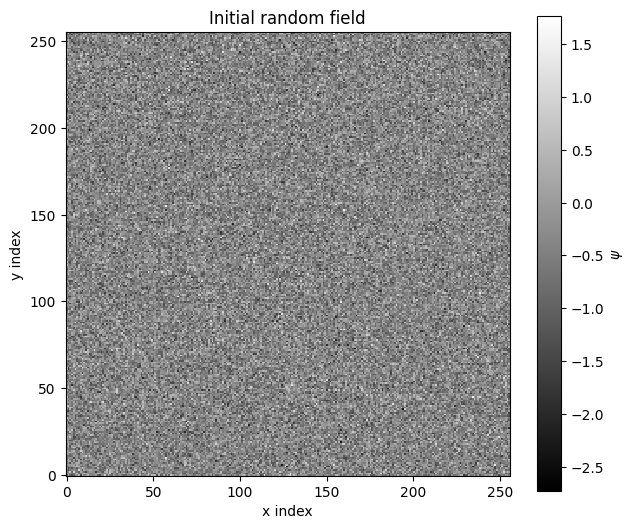

In [18]:
def plot_field(field, title):
    field_np = np.asarray(field)
    vmin = float(field_np.min())
    vmax = float(field_np.max())
    fig, ax = plt.subplots()
    image = ax.imshow(field_np, origin="lower", interpolation="nearest", vmin=vmin, vmax=vmax)
    ax.set_title(title)
    ax.set_xlabel("x index")
    ax.set_ylabel("y index")
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label("$\psi$")
    fig.tight_layout()
    plt.show()

plot_field(sim._payload_mgr.to_numpy(sim.psi), "Initial random field")

Completed 10000 steps
Final field stats: min=-0.890695, max=0.724959, mean=-0.398249


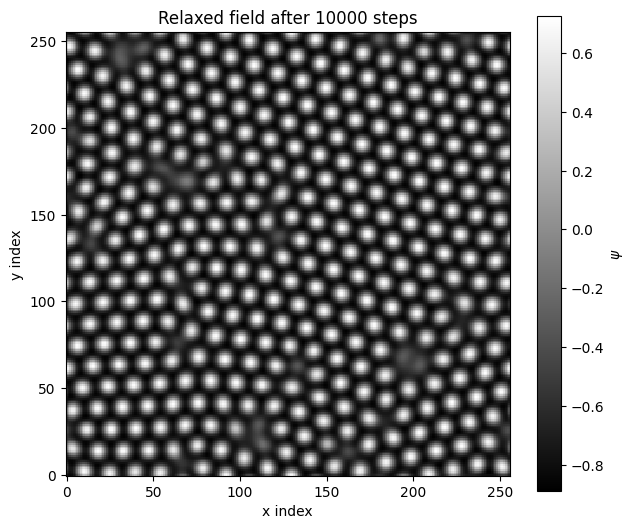

: 

In [ ]:
steps = 10000
for _ in range(steps):
    sim.step()

print(f"Completed {steps} steps")
print(f"Final field stats: min={np.min(sim.psi):.6f}, max={np.max(sim.psi):.6f}, mean={np.mean(sim.psi):.6f}")
plot_field(sim._payload_mgr.to_numpy(sim.psi), f"Relaxed field after {steps} steps")